In [14]:
# ==========================================
# Standard Libraries
# ==========================================

import os
import random
import warnings

# ==========================================
# Numerical Computing
# ==========================================

import numpy as np

# ==========================================
# Data Visualization
# ==========================================

import matplotlib.pyplot as plt

# ==========================================
# Deep Learning
# ==========================================

import torch
import torch.nn as nn
import torch.optim as optim

# ==========================================
# Data Loading
# ==========================================

from torch.utils.data import DataLoader

# ==========================================
# TorchVision
# ==========================================

from torchvision import datasets
from torchvision import transforms

from torchvision.utils import (
    save_image,
    make_grid
)

# ==========================================
# Progress Bar
# ==========================================

from tqdm import tqdm

# ==========================================
# Image Processing
# ==========================================

from PIL import Image

# ==========================================
# Ignore Warnings
# ==========================================

warnings.filterwarnings("ignore")

In [15]:
"""
config.py
Central configuration for the GAN-MNIST project.
"""

import os
import torch

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR = "./data"
CHECKPOINT_DIR = "./checkpoints"
SAMPLES_DIR = "./samples"
RESULTS_DIR = "./results"

BEST_GENERATOR_PATH = os.path.join(CHECKPOINT_DIR, "generator_best.pth")
BEST_DISCRIMINATOR_PATH = os.path.join(CHECKPOINT_DIR, "discriminator_best.pth")
LAST_GENERATOR_PATH = os.path.join(CHECKPOINT_DIR, "generator_last.pth")
LAST_DISCRIMINATOR_PATH = os.path.join(CHECKPOINT_DIR, "discriminator_last.pth")

LOSS_CURVE_PATH = os.path.join(RESULTS_DIR, "loss_curve.png")
GENERATED_GRID_PATH = os.path.join(RESULTS_DIR, "generated_grid.png")

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------
IMAGE_SIZE = 28
IMAGE_CHANNELS = 1

# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------
LATENT_DIM = 100
GEN_HIDDEN_DIM = 256
DISC_HIDDEN_DIM = 256

# ---------------------------------------------------------------------------
# Training hyperparameters
# ---------------------------------------------------------------------------
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
BETA1 = 0.5   # standard Adam beta1 for GAN training (DCGAN paper default)
BETA2 = 0.999
EPOCHS = 50
NUM_WORKERS = 2

# Label smoothing for the discriminator's "real" target (helps stability)
REAL_LABEL_SMOOTHING = 0.9

# How many fixed noise samples to decode and save each epoch
NUM_SAMPLE_IMAGES = 64

# Ensure required directories exist
for _dir in (DATA_DIR, CHECKPOINT_DIR, SAMPLES_DIR, RESULTS_DIR):
    os.makedirs(_dir, exist_ok=True)


First, we need to create the `config.py` file so that it can be imported by other modules. The content for `config.py` is taken directly from cell `_xTrwJM265JC`.

In [16]:
%%writefile config.py
"""
config.py
Central configuration for the GAN-MNIST project.
"""

import os
import torch

# ---------------------------------------------------------------------------
# Device
# ---------------------------------------------------------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
SEED = 42

# ---------------------------------------------------------------------------
# Paths
# ---------------------------------------------------------------------------
DATA_DIR = "./data"
CHECKPOINT_DIR = "./checkpoints"
SAMPLES_DIR = "./samples"
RESULTS_DIR = "./results"

BEST_GENERATOR_PATH = os.path.join(CHECKPOINT_DIR, "generator_best.pth")
BEST_DISCRIMINATOR_PATH = os.path.join(CHECKPOINT_DIR, "discriminator_best.pth")
LAST_GENERATOR_PATH = os.path.join(CHECKPOINT_DIR, "generator_last.pth")
LAST_DISCRIMINATOR_PATH = os.path.join(CHECKPOINT_DIR, "discriminator_last.pth")

LOSS_CURVE_PATH = os.path.join(RESULTS_DIR, "loss_curve.png")
GENERATED_GRID_PATH = os.path.join(RESULTS_DIR, "generated_grid.png")

# ---------------------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------------------
IMAGE_SIZE = 28
IMAGE_CHANNELS = 1

# ---------------------------------------------------------------------------
# Model
# ---------------------------------------------------------------------------
LATENT_DIM = 100
GEN_HIDDEN_DIM = 256
DISC_HIDDEN_DIM = 256

# ---------------------------------------------------------------------------
# Training hyperparameters
# ---------------------------------------------------------------------------
BATCH_SIZE = 128
LEARNING_RATE = 2e-4
BETA1 = 0.5   # standard Adam beta1 for GAN training (DCGAN paper default)
BETA2 = 0.999
EPOCHS = 50
NUM_WORKERS = 2

# Label smoothing for the discriminator's "real" target (helps stability)
REAL_LABEL_SMOOTHING = 0.9

# How many fixed noise samples to decode and save each epoch
NUM_SAMPLE_IMAGES = 64

# Ensure required directories exist
for _dir in (DATA_DIR, CHECKPOINT_DIR, SAMPLES_DIR, RESULTS_DIR):
    os.makedirs(_dir, exist_ok=True)

Overwriting config.py


In [17]:
"""
dataset.py
MNIST dataset loading for GAN training.

Images are normalized to [-1, 1] (mean=0.5, std=0.5) because the generator
uses a Tanh output activation, which is the standard convention for GANs.
"""

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

import config


def get_dataloader(
    batch_size: int = config.BATCH_SIZE,
    num_workers: int = config.NUM_WORKERS,
) -> DataLoader:
    """
    Returns a DataLoader over the full MNIST training set, normalized to
    [-1, 1]. GANs typically don't need a validation split since there is
    no single ground-truth loss to validate against.
    """
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )

    dataset = MNIST(
        root=config.DATA_DIR,
        train=True,
        download=True,
        transform=transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )

    return loader


def denormalize(images):
    """Maps images from [-1, 1] back to [0, 1] for saving/viewing."""
    return (images + 1) / 2


Now, we need to create the `dataset.py` file so that it can be imported by other modules, specifically `utils.py`. The content for `dataset.py` is taken directly from cell `6wOVgrOC7GER`.

In [18]:
%%writefile dataset.py
"""
dataset.py
MNIST dataset loading for GAN training.

Images are normalized to [-1, 1] (mean=0.5, std=0.5) because the generator
uses a Tanh output activation, which is the standard convention for GANs.
"""

from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

import config


def get_dataloader(
    batch_size: int = config.BATCH_SIZE,
    num_workers: int = config.NUM_WORKERS,
) -> DataLoader:
    """
    Returns a DataLoader over the full MNIST training set, normalized to
    [-1, 1]. GANs typically don't need a validation split since there is
    no single ground-truth loss to validate against.
    """
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )

    dataset = MNIST(
        root=config.DATA_DIR,
        train=True,
        download=True,
        transform=transform,
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True,
        drop_last=True,
    )

    return loader


def denormalize(images):
    """Maps images from [-1, 1] back to [0, 1] for saving/viewing."""
    return (images + 1) / 2

Overwriting dataset.py


In [19]:
"""
model.py
Generator and Discriminator networks for a fully-connected GAN on MNIST.

Generator:  noise (LATENT_DIM,) -> image (1, 28, 28), Tanh output in [-1, 1]
Discriminator: image (1, 28, 28) -> raw logit (real/fake), used with
                BCEWithLogitsLoss for numerical stability.
"""

import torch
import torch.nn as nn

import config


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = config.LATENT_DIM,
        hidden_dim: int = config.GEN_HIDDEN_DIM,
        image_size: int = config.IMAGE_SIZE,
        image_channels: int = config.IMAGE_CHANNELS,
    ):
        super().__init__()

        self.image_size = image_size
        self.image_channels = image_channels
        output_dim = image_channels * image_size * image_size

        def block(in_feat: int, out_feat: int, normalize: bool = True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, hidden_dim, normalize=False),
            *block(hidden_dim, hidden_dim * 2),
            *block(hidden_dim * 2, hidden_dim * 4),
            nn.Linear(hidden_dim * 4, output_dim),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.model(z)
        return out.view(-1, self.image_channels, self.image_size, self.image_size)


class Discriminator(nn.Module):
    def __init__(
        self,
        hidden_dim: int = config.DISC_HIDDEN_DIM,
        image_size: int = config.IMAGE_SIZE,
        image_channels: int = config.IMAGE_CHANNELS,
    ):
        super().__init__()

        input_dim = image_channels * image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, 1),  # raw logit, no sigmoid
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_flat = x.view(x.size(0), -1)
        return self.model(x_flat)


def weights_init(m: nn.Module) -> None:
    """Standard DCGAN-style weight initialization, applied via model.apply(weights_init)."""
    classname = m.__class__.__name__
    if classname.find("Linear") != -1:
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)


Next, we need to create the `model.py` file so that it can be imported by other modules, specifically `train.py`. The content for `model.py` is taken directly from cell `WcE3QczZ77I4`.

In [20]:
%%writefile model.py
"""
model.py
Generator and Discriminator networks for a fully-connected GAN on MNIST.

Generator:  noise (LATENT_DIM,) -> image (1, 28, 28), Tanh output in [-1, 1]
Discriminator: image (1, 28, 28) -> raw logit (real/fake), used with
                BCEWithLogitsLoss for numerical stability.
"""

import torch
import torch.nn as nn

import config


class Generator(nn.Module):
    def __init__(
        self,
        latent_dim: int = config.LATENT_DIM,
        hidden_dim: int = config.GEN_HIDDEN_DIM,
        image_size: int = config.IMAGE_SIZE,
        image_channels: int = config.IMAGE_CHANNELS,
    ):
        super().__init__()

        self.image_size = image_size
        self.image_channels = image_channels
        output_dim = image_channels * image_size * image_size

        def block(in_feat: int, out_feat: int, normalize: bool = True):
            layers = [nn.Linear(in_feat, out_feat)]
            if normalize:
                layers.append(nn.BatchNorm1d(out_feat))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(latent_dim, hidden_dim, normalize=False),
            *block(hidden_dim, hidden_dim * 2),
            *block(hidden_dim * 2, hidden_dim * 4),
            nn.Linear(hidden_dim * 4, output_dim),
            nn.Tanh(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        out = self.model(z)
        return out.view(-1, self.image_channels, self.image_size, self.image_size)


class Discriminator(nn.Module):
    def __init__(
        self,
        hidden_dim: int = config.DISC_HIDDEN_DIM,
        image_size: int = config.IMAGE_SIZE,
        image_channels: int = config.IMAGE_CHANNELS,
    ):
        super().__init__()

        input_dim = image_channels * image_size * image_size

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim * 4, hidden_dim * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),

            nn.Linear(hidden_dim, 1),  # raw logit, no sigmoid
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_flat = x.view(x.size(0), -1)
        return self.model(x_flat)


def weights_init(m: nn.Module) -> None:
    """Standard DCGAN-style weight initialization, applied via model.apply(weights_init)."""
    classname = m.__class__.__name__
    if classname.find("Linear") != -1:
        nn.init.normal_(m.weight, 0.0, 0.02)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight, 1.0, 0.02)
        nn.init.constant_(m.bias, 0)

Overwriting model.py


Next, we need to create the `loss.py` file so that it can be imported by other modules, specifically `train.py`. The content for `loss.py` is taken directly from cell `tNP5IIJz8EoY`.

In [25]:
%%writefile loss.py
"""
loss.py
Adversarial losses for GAN training, using BCEWithLogitsLoss since the
Discriminator outputs raw logits (more numerically stable than applying
Sigmoid + BCELoss separately).
"""

from typing import Tuple

import torch
import torch.nn as nn

import config

adversarial_loss = nn.BCEWithLogitsLoss()


def discriminator_loss(
    real_logits: torch.Tensor,
    fake_logits: torch.Tensor,
    real_label_smoothing: float = config.REAL_LABEL_SMOOTHING,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Standard discriminator loss: classify real images as real (1) and
    generated images as fake (0).

    real_label_smoothing < 1.0 softens the "real" target (e.g. 0.9 instead
    of 1.0), a common trick to prevent the discriminator from becoming
    overconfident and stabilize adversarial training.

    Returns (total_loss, real_loss, fake_loss).
    """
    real_targets = torch.full_like(real_logits, real_label_smoothing)
    fake_targets = torch.zeros_like(fake_logits)

    real_loss = adversarial_loss(real_logits, real_targets)
    fake_loss = adversarial_loss(fake_logits, fake_targets)

    total_loss = real_loss + fake_loss

    return total_loss, real_loss, fake_loss


def generator_loss(fake_logits: torch.Tensor) -> torch.Tensor:
    """
    Non-saturating generator loss: the generator wants the discriminator
    to classify its fake images as real (target = 1), which gives much
    stronger gradients early in training than the original minimax
    formulation (minimizing log(1 - D(G(z)))).
    """
    real_targets = torch.ones_like(fake_logits)
    return adversarial_loss(fake_logits, real_targets)

Writing loss.py


The `train.py` script (`kqfjrdY-8unh`) is now reporting a `ModuleNotFoundError` for `utils`. Similar to the previous modules, we need to save the content of cell `2XzU_jos8Q8R` as `utils.py` to make it importable.

In [27]:
%%writefile utils.py
"""
utils.py
Helper functions: reproducibility, checkpointing, sample-grid saving,
loss-curve plotting.
"""

import os
import random
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image

from dataset import denormalize


def set_seed(seed: int) -> None:
    """Make training as reproducible as practically possible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_checkpoint(
    path: str,
    epoch: int,
    model: nn.Module,
    optimizer: optim.Optimizer,
    extra: Optional[Dict[str, Any]] = None,
) -> None:
    checkpoint: Dict[str, Any] = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }
    if extra:
        checkpoint.update(extra)
    torch.save(checkpoint, path)


def load_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: Optional[optim.Optimizer] = None,
    device: str = "cpu",
) -> Dict[str, Any]:
    """
    Loads a checkpoint into model (and optionally optimizer).
    Returns the raw checkpoint dict so the caller can read epoch/etc.
    """
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return checkpoint


def save_sample_grid(
    images: torch.Tensor,
    epoch: int,
    samples_dir: str,
    nrow: int = 8,
) -> str:
    """
    Saves a grid of generated images (already in [-1, 1]) as a PNG for
    this epoch. Denormalizes to [0, 1] before writing. Returns the path.
    """
    os.makedirs(samples_dir, exist_ok=True)
    images_01 = denormalize(images).clamp(0, 1)
    out_path = os.path.join(samples_dir, f"epoch_{epoch:03d}.png")
    save_image(images_01, out_path, nrow=nrow)
    return out_path


def plot_loss_curve(
    g_losses,
    d_losses,
    output_path: str,
) -> None:
    """Plots generator and discriminator loss per epoch and saves to disk."""
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()

Writing utils.py


In [21]:
"""
loss.py
Adversarial losses for GAN training, using BCEWithLogitsLoss since the
Discriminator outputs raw logits (more numerically stable than applying
Sigmoid + BCELoss separately).
"""

from typing import Tuple

import torch
import torch.nn as nn

import config

adversarial_loss = nn.BCEWithLogitsLoss()


def discriminator_loss(
    real_logits: torch.Tensor,
    fake_logits: torch.Tensor,
    real_label_smoothing: float = config.REAL_LABEL_SMOOTHING,
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Standard discriminator loss: classify real images as real (1) and
    generated images as fake (0).

    real_label_smoothing < 1.0 softens the "real" target (e.g. 0.9 instead
    of 1.0), a common trick to prevent the discriminator from becoming
    overconfident and stabilize adversarial training.

    Returns (total_loss, real_loss, fake_loss).
    """
    real_targets = torch.full_like(real_logits, real_label_smoothing)
    fake_targets = torch.zeros_like(fake_logits)

    real_loss = adversarial_loss(real_logits, real_targets)
    fake_loss = adversarial_loss(fake_logits, fake_targets)

    total_loss = real_loss + fake_loss

    return total_loss, real_loss, fake_loss


def generator_loss(fake_logits: torch.Tensor) -> torch.Tensor:
    """
    Non-saturating generator loss: the generator wants the discriminator
    to classify its fake images as real (target = 1), which gives much
    stronger gradients early in training than the original minimax
    formulation (minimizing log(1 - D(G(z)))).
    """
    real_targets = torch.ones_like(fake_logits)
    return adversarial_loss(fake_logits, real_targets)


In [30]:
                                                                                                            import argparse
import os

import torch
import torch.optim as optim
from torchvision.utils import save_image
from tqdm import tqdm

import config
from dataset import get_dataloader
from model import Generator, Discriminator, weights_init
from loss import discriminator_loss, generator_loss
from utils import (
    save_checkpoint,
    load_checkpoint,
    save_sample_grid,
    plot_loss_curve,
    set_seed,
)


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Train a GAN on MNIST")
    parser.add_argument(
        "--epochs", type=int, default=config.EPOCHS, help="Number of epochs"
    )
    parser.add_argument(
        "--batch-size", type=int, default=config.BATCH_SIZE, help="Batch size"
    )
    parser.add_argument(
        "--lr", type=float, default=config.LEARNING_RATE, help="Learning rate"
    )
    parser.add_argument(
        "--resume",
        action="store_true",
        help="Resume training from the last checkpoint if it exists",
    )
    return parser.parse_args(args)


def main() -> None:
    # When running in a notebook, sys.argv will contain kernel-specific arguments
    # that argparse doesn't know about. We can pass an empty list to parse_args()
    # to prevent it from trying to parse these unknown arguments.
    # If you want to use command-line arguments in the notebook, you can replace
    # `[]` with a list of strings, e.g., `['--epochs', '10']`
    args = parse_args([])
    set_seed(config.SEED)

    device = config.DEVICE
    print(f"Using device: {device}")

    dataloader = get_dataloader(batch_size=args.batch_size)

    generator = Generator().to(device)
    discriminator = Discriminator().to(device)
    generator.apply(weights_init)
    discriminator.apply(weights_init)

    opt_g = optim.Adam(
        generator.parameters(), lr=args.lr, betas=(config.BETA1, config.BETA2)
    )
    opt_d = optim.Adam(
        discriminator.parameters(), lr=args.lr, betas=(config.BETA1, config.BETA2)
    )

    start_epoch = 1
    best_g_loss = float("inf")
    g_loss_history = []
    d_loss_history = []

    # ------------------------------------------------------------------
    # Resume from checkpoint if requested and available
    # ------------------------------------------------------------------
    if args.resume and os.path.exists(config.LAST_GENERATOR_PATH):
        print(f"Resuming from {config.LAST_GENERATOR_PATH}")
        g_checkpoint = load_checkpoint(
            config.LAST_GENERATOR_PATH, generator, opt_g, device=device
        )
        d_checkpoint = load_checkpoint(
            config.LAST_DISCRIMINATOR_PATH, discriminator, opt_d, device=device
        )
        start_epoch = g_checkpoint["epoch"] + 1
        best_g_loss = g_checkpoint.get("best_g_loss", float("inf"))
        g_loss_history = g_checkpoint.get("g_loss_history", [])
        d_loss_history = d_checkpoint.get("d_loss_history", [])
        print(f"Resumed at epoch {start_epoch}")

    # Fixed noise so the sample grid is visually comparable across epochs
    fixed_noise = torch.randn(
        config.NUM_SAMPLE_IMAGES, config.LATENT_DIM, device=device
    )

    print("\nTraining started...\n")

    for epoch in range(start_epoch, args.epochs + 1):
        generator.train()
        discriminator.train()

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0
        n_batches = 0

        progress = tqdm(dataloader, desc=f"Epoch {epoch}/{args.epochs}", leave=False)

        for real_images, _ in progress:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # ============================================================
            # 1. Train Discriminator
            # ============================================================
            noise = torch.randn(batch_size, config.LATENT_DIM, device=device)
            fake_images = generator(noise)

            real_logits = discriminator(real_images)
            fake_logits = discriminator(fake_images.detach())

            d_loss, d_real_loss, d_fake_loss = discriminator_loss(
                real_logits, fake_logits
            )

            opt_d.zero_grad()
            d_loss.backward()
            opt_d.step()

            # ============================================================
            # 2. Train Generator
            # ============================================================
            fake_logits_for_g = discriminator(fake_images)
            g_loss = generator_loss(fake_logits_for_g)

            opt_g.zero_grad()
            g_loss.backward()
            opt_g.step()

            epoch_g_loss += g_loss.item()
            epoch_d_loss += d_loss.item()
            n_batches += 1

            progress.set_postfix(
                g_loss=g_loss.item(), d_loss=d_loss.item()
            )

        avg_g_loss = epoch_g_loss / n_batches
        avg_d_loss = epoch_d_loss / n_batches
        g_loss_history.append(avg_g_loss)
        d_loss_history.append(avg_d_loss)

        print(
            f"Epoch {epoch}/{args.epochs} | "
            f"g_loss={avg_g_loss:.4f} | d_loss={avg_d_loss:.4f}"
        )

        # ---------------- Save sample grid for this epoch ----------------
        generator.eval()
        with torch.no_grad():
            samples = generator(fixed_noise).cpu()
        sample_path = save_sample_grid(samples, epoch, config.SAMPLES_DIR, nrow=8)
        print(f"Saved sample grid to {sample_path}")

        # ---------------- Checkpointing ----------------
        extra = {
            "best_g_loss": min(best_g_loss, avg_g_loss),
            "g_loss_history": g_loss_history,
        }
        save_checkpoint(config.LAST_GENERATOR_PATH, epoch, generator, opt_g, extra)
        save_checkpoint(
            config.LAST_DISCRIMINATOR_PATH,
            epoch,
            discriminator,
            opt_d,
            {"d_loss_history": d_loss_history},
        )

        if avg_g_loss < best_g_loss:
            best_g_loss = avg_g_loss
            save_checkpoint(config.BEST_GENERATOR_PATH, epoch, generator, opt_g, extra)
            save_checkpoint(
                config.BEST_DISCRIMINATOR_PATH,
                epoch,
                discriminator,
                opt_d,
                {"d_loss_history": d_loss_history},
            )
            print(f"New best generator saved (g_loss={best_g_loss:.4f})")

    print("\nTraining complete.")

    # ---------------- Final artifacts ----------------
    plot_loss_curve(g_loss_history, d_loss_history, config.LOSS_CURVE_PATH)
    print(f"Saved loss curve to {config.LOSS_CURVE_PATH}")

    generator.eval()
    with torch.no_grad():
        final_samples = generator(fixed_noise).cpu()
    from dataset import denormalize
    save_image(
        denormalize(final_samples).clamp(0, 1), config.GENERATED_GRID_PATH, nrow=8
    )
    print(f"Saved final generated grid to {config.GENERATED_GRID_PATH}")

    print(f"\nBest generator checkpoint: {config.BEST_GENERATOR_PATH}")
    print(f"Last generator checkpoint: {config.LAST_GENERATOR_PATH}")


if __name__ == "__main__":
    main()


Using device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.78MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 12.8MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.74MB/s]



Training started...



Epoch 1/50 | g_loss=0.9286 | d_loss=1.3264
Saved sample grid to ./samples/epoch_001.png
New best generator saved (g_loss=0.9286)


Epoch 2/50 | g_loss=1.0996 | d_loss=1.2655
Saved sample grid to ./samples/epoch_002.png


...

Epoch 46/50 | g_loss=0.9230 | d_loss=1.3274
Saved sample grid to ./samples/epoch_046.png
New best generator saved (g_loss=0.9230)


Epoch 47/50 | g_loss=0.9263 | d_loss=1.3256
Saved sample grid to ./samples/epoch_047.png


Epoch 48/50 | g_loss=0.9218 | d_loss=1.3285
Saved sample grid to ./samples/epoch_048.png
New best generator saved (g_loss=0.9218)


Epoch 49/50 | g_loss=0.9166 | d_loss=1.3285
Saved sample grid to ./samples/epoch_049.png
New best generator saved (g_loss=0.9166)


Epoch 50/50 | g_loss=0.9178 | d_loss=1.3283
Saved sample grid to ./samples/epoch_050.png

Training complete.
Saved loss curve to ./results/loss_curve.png
Saved final generated grid to ./results/generated_grid.png

Best generator checkpoint: ./checkpoints/generator_best.pth
Last generator checkpoint: ./checkpoints/generator_last.pth


In [31]:
"""
utils.py
Helper functions: reproducibility, checkpointing, sample-grid saving,
loss-curve plotting.
"""

import os
import random
from typing import Any, Dict, Optional

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.utils import save_image

from dataset import denormalize


def set_seed(seed: int) -> None:
    """Make training as reproducible as practically possible."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def save_checkpoint(
    path: str,
    epoch: int,
    model: nn.Module,
    optimizer: optim.Optimizer,
    extra: Optional[Dict[str, Any]] = None,
) -> None:
    checkpoint: Dict[str, Any] = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }
    if extra:
        checkpoint.update(extra)
    torch.save(checkpoint, path)


def load_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: Optional[optim.Optimizer] = None,
    device: str = "cpu",
) -> Dict[str, Any]:
    """
    Loads a checkpoint into model (and optionally optimizer).
    Returns the raw checkpoint dict so the caller can read epoch/etc.
    """
    checkpoint = torch.load(path, map_location=device)

    model.load_state_dict(checkpoint["model_state_dict"])

    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    return checkpoint


def save_sample_grid(
    images: torch.Tensor,
    epoch: int,
    samples_dir: str,
    nrow: int = 8,
) -> str:
    """
    Saves a grid of generated images (already in [-1, 1]) as a PNG for
    this epoch. Denormalizes to [0, 1] before writing. Returns the path.
    """
    os.makedirs(samples_dir, exist_ok=True)
    images_01 = denormalize(images).clamp(0, 1)
    out_path = os.path.join(samples_dir, f"epoch_{epoch:03d}.png")
    save_image(images_01, out_path, nrow=nrow)
    return out_path


def plot_loss_curve(
    g_losses,
    d_losses,
    output_path: str,
) -> None:
    """Plots generator and discriminator loss per epoch and saves to disk."""
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)

    plt.figure(figsize=(10, 6))
    plt.plot(g_losses, label="Generator loss")
    plt.plot(d_losses, label="Discriminator loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("GAN Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.close()


In [33]:
"""
generate.py
Loads a trained Generator checkpoint and synthesizes new digits from
random noise.

Importable usage (e.g. from a notebook):
    from generate import generate
    images = generate(num_images=16)

Command-line usage:
    python generate.py
    python generate.py --num-images 64
    python generate.py --checkpoint checkpoints/generator_last.pth
"""

import argparse
import os

import torch
from torchvision.utils import save_image

import config
from dataset import denormalize
from model import Generator

_cached_model = None
_cached_checkpoint_path = None


def load_generator(checkpoint_path: str, device: str) -> Generator:
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"No checkpoint found at {checkpoint_path}. Run train.py first."
        )

    model = Generator().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    epoch = checkpoint.get("epoch", "unknown")
    print(f"Loaded generator checkpoint from epoch {epoch}")

    return model


def generate(
    num_images: int = 16,
    checkpoint_path: str = config.BEST_GENERATOR_PATH,
    device: str = config.DEVICE,
    save: bool = True,
    output_path: str = None,
) -> torch.Tensor:
    """
    Generates `num_images` new digits from random noise.

    Reuses a cached Generator across calls (so repeated calls in a
    notebook don't reload the checkpoint from disk every time), unless a
    different checkpoint_path is requested.

    Returns a tensor of shape (num_images, channels, H, W) in [0, 1].
    """
    global _cached_model, _cached_checkpoint_path

    if _cached_model is None or _cached_checkpoint_path != checkpoint_path:
        _cached_model = load_generator(checkpoint_path, device)
        _cached_checkpoint_path = checkpoint_path

    with torch.no_grad():
        noise = torch.randn(num_images, config.LATENT_DIM, device=device)
        images = _cached_model(noise)

    images = denormalize(images).clamp(0, 1)

    if save:
        output_path = output_path or os.path.join(
            "./generated", f"generated_{num_images}.png"
        )
        os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
        nrow = int(num_images ** 0.5) or 1
        save_image(images, output_path, nrow=nrow)
        print(f"Saved {num_images} generated digits to {output_path}")

    return images


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Generate digits from a trained GAN")
    parser.add_argument(
        "--num-images", type=int, default=16, help="Number of images to generate"
    )
    parser.add_argument(
        "--checkpoint",
        type=str,
        default=config.BEST_GENERATOR_PATH,
        help="Path to a generator checkpoint saved by train.py",
    )
    parser.add_argument(
        "--output",
        type=str,
        default=None,
        help="Where to save the generated grid (default: ./generated/generated_N.png)",
    )
    parser.add_argument(
        "--seed", type=int, default=None, help="Optional random seed"
    )
    return parser.parse_args(args)


def main() -> None:
    # When running in a notebook, sys.argv will contain kernel-specific arguments
    # that argparse doesn't know about. We can pass an empty list to parse_args()
    # to prevent it from trying to parse these unknown arguments.
    # If you want to use command-line arguments in the notebook, you can replace
    # `[]` with a list of strings, e.g., `['--num-images', '10']`
    args = parse_args([])

    if args.seed is not None:
        torch.manual_seed(args.seed)

    generate(
        num_images=args.num_images,
        checkpoint_path=args.checkpoint,
        device=config.DEVICE,
        save=True,
        output_path=args.output,
    )


if __name__ == "__main__":
    main()


Loaded generator checkpoint from epoch 49
Saved 16 generated digits to ./generated/generated_16.png


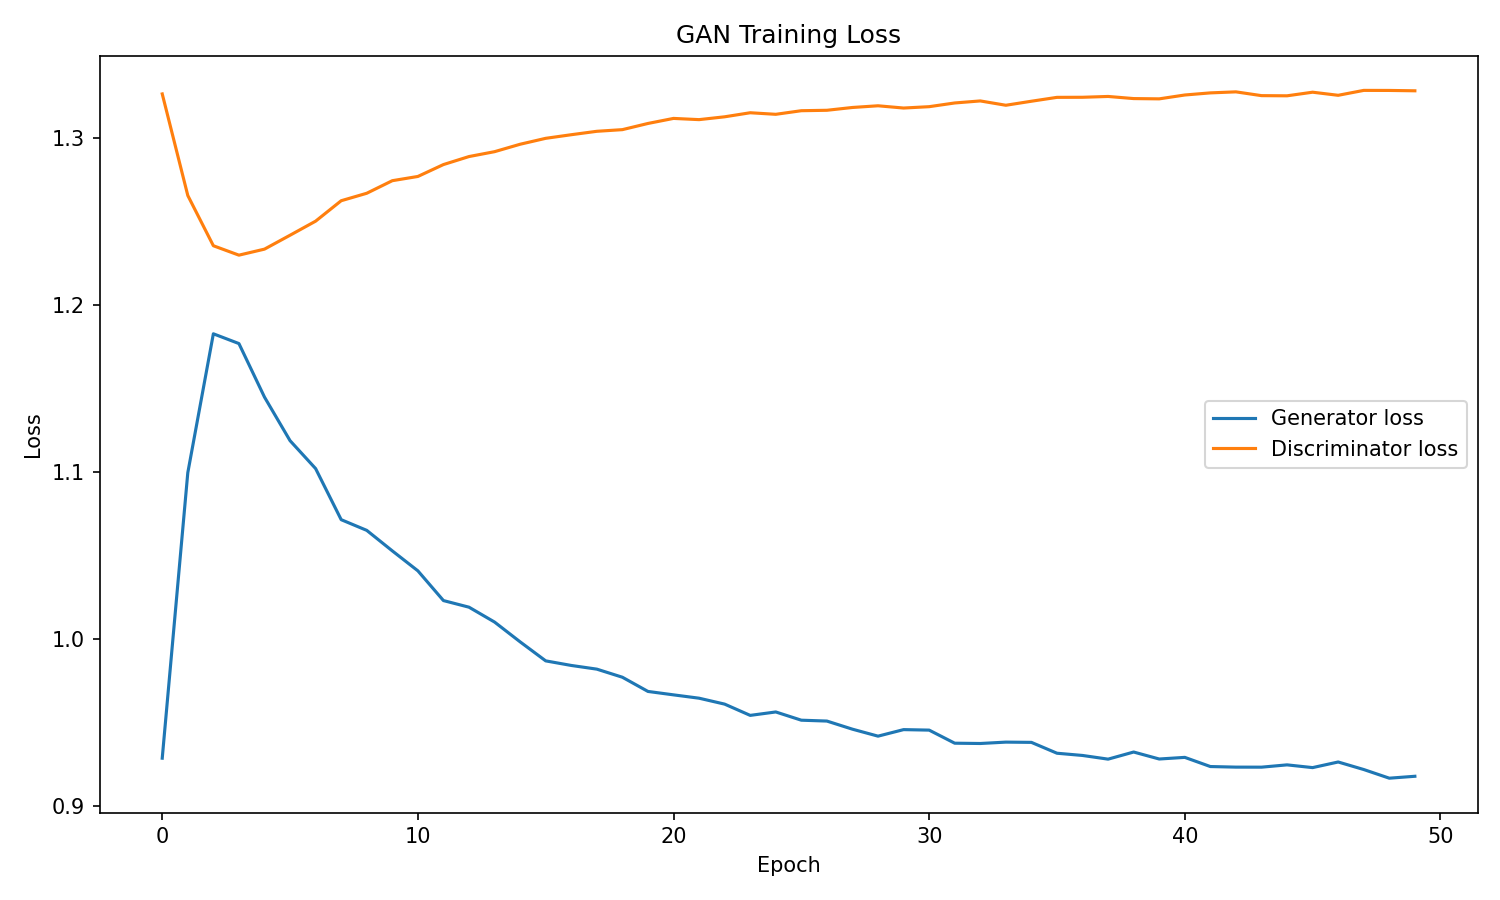

In [34]:
from IPython.display import Image
import config

# Display the saved loss curve
Image(filename=config.LOSS_CURVE_PATH)

In [36]:
import argparse
import os

import torch
from torchvision.utils import save_image

import config
from dataset import denormalize
from model import Generator


def load_generator(checkpoint_path: str, device: str) -> Generator:
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(
            f"No checkpoint found at {checkpoint_path}. Run train.py first."
        )

    model = Generator().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    return model


@torch.no_grad()
def run_inference(
    checkpoint_path: str = config.BEST_GENERATOR_PATH,
    num_images: int = config.NUM_SAMPLE_IMAGES,
    output_path: str = config.GENERATED_GRID_PATH,
    device: str = config.DEVICE,
    seed: int = None,
) -> str:
    """
    Loads the generator and writes a single demo grid to disk.
    Returns the path written.
    """
    if seed is not None:
        torch.manual_seed(seed)

    model = load_generator(checkpoint_path, device)

    noise = torch.randn(num_images, config.LATENT_DIM, device=device)
    images = model(noise)
    images = denormalize(images).clamp(0, 1)

    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    nrow = int(num_images ** 0.5) or 1
    save_image(images, output_path, nrow=nrow)

    return output_path


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Run inference with a trained GAN-MNIST generator"
    )
    parser.add_argument(
        "--checkpoint",
        type=str,
        default=config.BEST_GENERATOR_PATH,
        help="Path to a generator checkpoint",
    )
    parser.add_argument(
        "--num-images",
        type=int,
        default=config.NUM_SAMPLE_IMAGES,
        help="How many digits to generate",
    )
    parser.add_argument(
        "--output",
        type=str,
        default=config.GENERATED_GRID_PATH,
        help="Where to save the output grid",
    )
    parser.add_argument("--seed", type=int, default=None, help="Optional random seed")
    return parser.parse_args(args)


def main() -> None:
    # When running in a notebook, sys.argv will contain kernel-specific arguments
    # that argparse doesn't know about. We can pass an empty list to parse_args()
    # to prevent it from trying to parse these unknown arguments.
    # If you want to use command-line arguments in the notebook, you can replace
    # `[]` with a list of strings, e.g., `['--num-images', '10']`
    args = parse_args([])
    out_path = run_inference(
        checkpoint_path=args.checkpoint,
        num_images=args.num_images,
        output_path=args.output,
        device=config.DEVICE,
        seed=args.seed,
    )
    print(f"Inference complete. Saved grid to {out_path}")


if __name__ == "__main__":
    main()


Inference complete. Saved grid to ./results/generated_grid.png


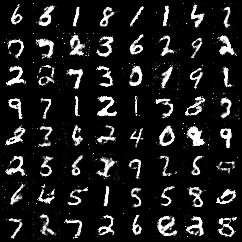

In [37]:
from IPython.display import Image
import config

# Display the generated image grid
Image(filename=config.GENERATED_GRID_PATH)

In [38]:
import torch
import torch.optim as optim
import os

from model import Generator, Discriminator
from utils import load_checkpoint, save_checkpoint
import config

# Define paths for new exported models
EXPORTED_GENERATOR_PATH = os.path.join(config.CHECKPOINT_DIR, "generator_exported.pth")
EXPORTED_DISCRIMINATOR_PATH = os.path.join(config.CHECKPOINT_DIR, "discriminator_exported.pth")

try:
    print("Loading best trained models to re-save...")
    # Instantiate models
    generator = Generator().to(config.DEVICE)
    discriminator = Discriminator().to(config.DEVICE)

    # Instantiate dummy optimizers (needed for load_checkpoint signature, but not for just saving weights)
    opt_g = optim.Adam(generator.parameters(), lr=config.LEARNING_RATE, betas=(config.BETA1, config.BETA2))
    opt_d = optim.Adam(discriminator.parameters(), lr=config.LEARNING_RATE, betas=(config.BETA1, config.BETA2))

    # Load the best checkpoints (which were saved by train.py)
    g_checkpoint_data = load_checkpoint(config.BEST_GENERATOR_PATH, generator, opt_g, device=config.DEVICE)
    d_checkpoint_data = load_checkpoint(config.BEST_DISCRIMINATOR_PATH, discriminator, opt_d, device=config.DEVICE)
    print("Successfully loaded best trained Generator and Discriminator.")

    # Now, save them again to the new 'exported' paths
    save_checkpoint(EXPORTED_GENERATOR_PATH, g_checkpoint_data['epoch'], generator, opt_g, g_checkpoint_data)
    save_checkpoint(EXPORTED_DISCRIMINATOR_PATH, d_checkpoint_data['epoch'], discriminator, opt_d, d_checkpoint_data)

    print(f"\nModel saved! Generator exported to: {EXPORTED_GENERATOR_PATH}")
    print(f"Model saved! Discriminator exported to: {EXPORTED_DISCRIMINATOR_PATH}")

except FileNotFoundError as e:
    print(f"Error: Could not find trained model checkpoints. Please ensure train.py was run to completion. Details: {e}")
except Exception as e:
    print(f"An error occurred while loading or saving models: {e}")

Loading best trained models to re-save...
Successfully loaded best trained Generator and Discriminator.

Model saved! Generator exported to: ./checkpoints/generator_exported.pth
Model saved! Discriminator exported to: ./checkpoints/discriminator_exported.pth
